In [2]:
from pathlib import Path
import sys
import os

# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))

import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler
import cupy as cp
from tqdm import tqdm
from shapely.geometry import Point, Polygon
from scipy.signal import czt

In [2]:
#  Setting up real and Fourier space grid for czt
#------------------------------------------------------------------------------- 
wavelength = 550e-9
k = 2 * np.pi / wavelength
# x-limits
xmin = -2*wavelength
xmax = 2*wavelength
# y-limits
ymin = -2*wavelength
ymax = 2*wavelength
# samples in real space
Nx = 512
x0 = np.linspace(xmin, xmax, Nx)
y0 = np.linspace(ymin, ymax, Nx)
x,y =  np.meshgrid(x0, y0)
z = 0

kscale = k
kshift = 0*5*wavelength
# k range
kmin = -kscale+kshift
kmax = kscale+kshift
# samples in k space
Nkx = 512
k0 = np.linspace(kmin, kmax, Nkx)
kx,ky = np.meshgrid(k0, k0)


In [3]:
#  Parameters for czt
#------------------------------------------------------------------------------- 
a = -1
ak = 1

dx  = abs(x0[2]-x0[1])
dkx = abs(k0[2] - k0[1])

Wkx=np.exp(-1j*ak*dx*dkx)
Wx =np.exp(-1j*a *dx*dkx)      # used in IFT
Akx=np.exp( 1j*ak*kmin*dx)
Ax =np.exp( 1j*a*xmin*dkx)     # used in IFT
Ay = np.exp( 1j*a*ymin*dkx)     # used in IFT
# these factors account for the shift of origin using shift theorem
pkx = np.exp(-ak*1j*(xmin)*k0)
pky = np.exp(-ak*1j*(ymin)*k0)
px  = np.exp(-a* 1j*(kmin)*x0)

In [4]:
# Setup mask to bandlimit the fourier space
#------------------------------------------------------------------------------- 
kappa = np.sqrt(kx**2+ky**2)
kz_arg = k**2 - kappa**2
kz = np.zeros_like(kz_arg)
mask = kz_arg > 0
kz[mask] = np.sqrt(kz_arg[mask])
kz[~mask] = 1e-100

In [5]:
def get_e_theta_phi(
    k_x: np.ndarray | cp.ndarray,
    k_y: np.ndarray | cp.ndarray,
    k_z: np.ndarray | cp.ndarray,
) -> tuple[np.ndarray | cp.ndarray, np.ndarray | cp.ndarray]:
    """Get the theta and phi spherical polar basis vectors associated with
    a plane wave with given wavevector. The wavevector is assumed to be
    normalized."""
    xp = array_utils.get_module(k_x)
   
    mod_kappa = xp.sqrt((k_x**2 + k_y**2))
    
    # Find indices where k is parallel to z
    bad_indices = xp.where(xp.isclose(mod_kappa, 0.0))
    num_bad_indices = len(bad_indices[0])

    # Do the cross product and normalize (e_phi = z cross k)
    e_phi = xp.empty((*k_x.shape, 3))
    e_phi[..., 0] = k_y
    e_phi[..., 1] = -k_x
    e_phi[..., 2] = 0.0
    e_phi /= mod_kappa[..., xp.newaxis]
    e_phi[bad_indices] = xp.column_stack(
        (
            xp.zeros(num_bad_indices),
            k_z[bad_indices],
            xp.zeros(num_bad_indices),
        )
    )
    

    # e_theta = e_phi cross k
    e_theta = xp.empty((*k_x.shape, 3))
    e_theta[..., 0] = k_x * k_z
    e_theta[..., 1] = k_y * k_z
    e_theta[..., 2] = -(mod_kappa**2)
   
    # e_theta /= (mod_kappa[..., xp.newaxis]*kz)
    e_theta /= xp.sqrt(
    e_theta[..., 0] ** 2 + e_theta[..., 1] ** 2 + e_theta[..., 2] ** 2
)[..., xp.newaxis]
    e_theta[bad_indices] = xp.column_stack(
        (
            xp.ones(num_bad_indices),
            xp.zeros(num_bad_indices),
            xp.zeros(num_bad_indices),
        )
    )
    return e_theta, e_phi

In [ ]:
# simulation_name = "large_spheres"
# ism = InputStatisticsManager.from_name(simulation_name)
# pm = ism.get_matrix_pool_manager()
# pm.load_single_pool_S()
# -----------------------------------------------------------------------------
# Simulation parameters
# -----------------------------------------------------------------------------

wavelength = 550e-9
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

# 2D version
particle_statistics_2d = ParticleStatistics(
    term,
    isotropic_sphere.get_A,
    isotropic_sphere.get_A_product,
    isotropic_sphere.get_A_product_conj,
)
medium_statistics_2d = MediumStatistics([particle_statistics_2d])

my_grid = mode_grid_factory.from_tiling(
    tiling_type="rectangles",
    side_length=(0.05, 0.05),
    r_lim=1.2,
    grid_wave_type="propagating",
    rotation_angle=0.0,
    translation_vector=np.array([0.0, 0.0]),
)
my_grid.plot()
print(my_grid.num_propagating)

use_np_config = IntegrationTaskConfig(use_gpu=False)

num_modes = my_grid.num_propagating
print(f"Starting num_modes = {num_modes}")
# 2D
simulation_name = f"memory_effect"
input_statistics_manager_2d = InputStatisticsManager(
    simulation_name,
    medium_parameters,
    medium_statistics_2d,
    my_grid,
    supplied_indices=None,
    use_dirac_density=False,
    integration_method="midpoint",
    covariance_cubature_scheme=None,
    integration_task_config=use_np_config,
)
pool = input_statistics_manager_2d.get_matrix_pool_manager()

pool.populate_single_pool(2, use_cupy=False)

In [3]:
simulation_name = "memory_effect_test"
ism = InputStatisticsManager.from_name(simulation_name,parent_data_dir='/mnt/raid/rmt/data/')
pm = ism.get_matrix_pool_manager()


Loading statistics from memory...


In [4]:
pm.populate_single_pool(2, use_cupy=False, symmetrize=False)
# pm.load_single_pool_S()

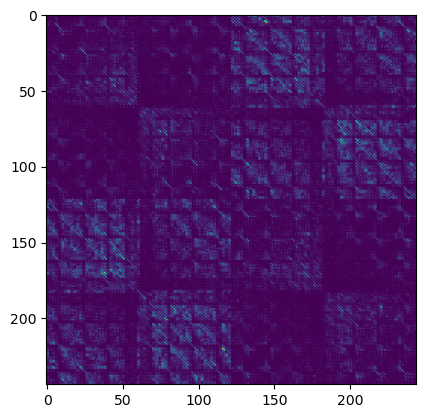

In [5]:
plt.imshow(np.abs(pm.S[0]))

In [ ]:
# S = pm.single_pool_S[0]
# t = matrix_utils.get_block(S, "t")
# t = t - np.identity(len(t))

In [9]:
def mode_indices(n: int, mode: int):
    """
    Return the two indices in a length-2*n vector E corresponding to `mode`.
    - n must be odd.
    - modes run from -n//2 .. +n//2 and are stored in ascending order.
    """
    if n % 2 == 0:
        raise ValueError("n must be odd")
    half = n // 2
    if mode < -half or mode > half:
        raise ValueError(f"mode must be between {-half} and {half}")
    start = (mode + half) * 2
    return start, start + 1

def mode_slice(n: int, mode: int):
    """Return a slice you can use to extract the two values: E[mode_slice(n,mode)]."""
    s, e = mode_indices(n, mode)
    return slice(s, e + 1)

In [7]:
def find_mode_index_by_point(my_grid, kx: float, ky: float, wave_type: str = "propagating") -> str | None:
    """
    Returns the index of the mode whose polygon contains or touches the given (kx, ky).

    Parameters
    ----------
    kx : float
        kx coordinate
    ky : float
        ky coordinate
    wave_type : str
        "propagating" or "evanescent"

    Returns
    -------
    index : str or None
        Index of the containing/touching mode, or None if not found
    """
    point = Point(kx, ky)
    for key, mode in my_grid.modes.items():
        if key[1] != wave_type:
            continue
        verts = np.array(mode.vertices)
        polygon = Polygon(verts)
        if polygon.contains(point) or polygon.touches(point):
            return key[0]
    return None

In [101]:
my_grid = mode_grid_factory.from_tiling(
    tiling_type="rectangles",
    side_length=(0.05, 0.05),
    r_lim=1.2,
    grid_wave_type="propagating",
    rotation_angle=0.0,
    translation_vector=np.array([0.0, 0.0]),
)
n = my_grid.num_propagating
print(f"Number of propagating modes: {n}")

Number of propagating modes: 1345


In [110]:
find_mode_index_by_point(my_grid,0.05, 0.0, wave_type="propagating")

'-632'

In [6]:
with open('/mnt/raid/rmt/data/memory_effect_test/mode_grid.pkl', 'rb') as f:
    my_grid = pickle.load(f)

In [7]:
n=61

In [84]:
i, j, u, v =0,-22,13,21

columns_to_keep = [0, 1, 2, 3, 4, 5]
mode_vertices_dict = my_grid.propagating_modes_vertices_dict
mode_i_vertices = mode_vertices_dict.get(i)
mode_j_vertices = mode_vertices_dict.get(j)
mode_u_vertices = mode_vertices_dict.get(u)
mode_v_vertices = mode_vertices_dict.get(v)

# Get the integration domain
# This part does the geometry with the 8D region being intersected
# by hyperplanes
cartesian_product = geometry_utils.iterated_cartesian_product(
    [
        mode_i_vertices,
        mode_j_vertices,
        mode_u_vertices,
        mode_v_vertices,
    ]
)
reduced_intersection = geometry_utils.get_intersection_vertices(
    cartesian_product
)[:, columns_to_keep]
reduced_hull = scipy.spatial.ConvexHull(
    reduced_intersection, qhull_options="QJ"
)
centroid = np.mean(cartesian_product, axis=0)
volume = reduced_hull.volume
print(volume)

0.0001922266711924188


[[0.00033787 0.00035222]
 [0.00035222 0.00037079]]


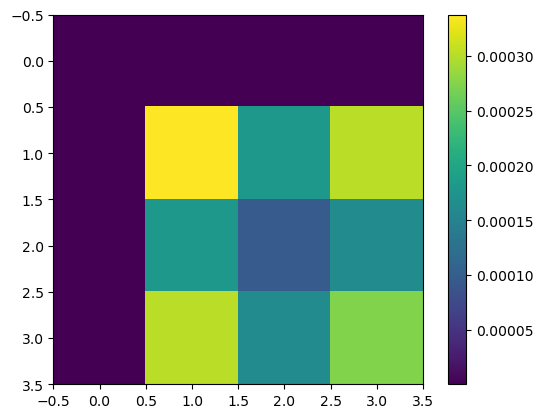

In [88]:
num_samples = 10**3
S = pm.S_sampler(num_samples, False)
incident_indices = (0, -22)
measured_indices = (29,-24)


Ei_normal = np.zeros(2 * n, dtype=complex)
Ei_normal[mode_slice(n, incident_indices[0])] = np.array(
    [1, 0]
)  # np.random.randn(2) + 1j*np.random.randn(2)

Ei_tilted = np.zeros(2 * n, dtype=complex)
Ei_tilted[mode_slice(n, incident_indices[1])] = np.array(
    [1, 0]
)  # np.random.randn(2) + 1j*np.random.randn(2)

scat_corr = np.zeros((4, 4), dtype=np.complex128)
for scat in S:

    t = matrix_utils.get_block(scat, "t")
    Et_normal = t @ Ei_normal
    Et_tilted = t @ Ei_tilted

    Et_normal_center = Et_normal[mode_slice(n, measured_indices[0])]
    Et_normal_off = Et_normal[mode_slice(n, measured_indices[1])]

    Et_tilted_center = Et_tilted[mode_slice(n, measured_indices[0])]
    Et_tilted_off = Et_tilted[mode_slice(n, measured_indices[1])]

    combined = np.concatenate([Et_normal_center, Et_tilted_off])
    outer = np.outer(combined, np.conj(combined))
    scat_corr += outer
scat_corr /= num_samples

fig, ax = plt.subplots()
im = ax.imshow(np.abs(scat_corr))
fig.colorbar(im, ax=ax)
# Es = E[0::2]
# Ep = E[1::2]
print(
    np.array(
        [
            [
                np.linalg.norm(scat_corr[0:2, 0:2]),
                np.linalg.norm(scat_corr[0:2, 2:4]),
            ],
            [
                np.linalg.norm(scat_corr[2:4, 0:2]),
                np.linalg.norm(scat_corr[2:4, 2:4]),
            ],
        ]
    )
)

In [98]:
bools = []
for _ in range(10**4):
    test = np.random.randn(4) + 1j*np.random.randn(4)
    out = np.outer(test, test)

    aa = np.linalg.norm(out[0:2,0:2])
    bb = np.linalg.norm(out[2:4,2:4])
    ab = np.linalg.norm(out[0:2,2:4])

    test_condition = ab > min(aa,bb) and ab < max(aa,bb)
    bools.append(test_condition)
np.all(test_condition)

True

In [52]:
Et_tilted_off

array([ 1.24939744e-06+0.00057887j, -4.68672671e-04+0.00822511j])

In [43]:
print(Et_normal.shape)

(122,)


In [47]:
indices = [2,7,14,22,0,-22,-14,-7,-2]
Et_normal_x = np.array([Et_normal[mode_slice(n, index)] for index in indices])
Et_tilted_x = np.array([Et_tilted[mode_slice(n, index)] for index in indices])
print(Et_normal_x[:,0].shape)

(9,)


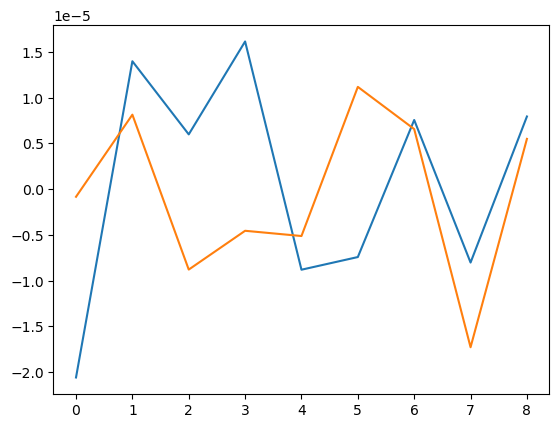

In [49]:
fig, ax = plt.subplots()
ax.plot(range(9), Et_normal_x[:,1].real)
ax.plot(range(9), Et_tilted_x[:,1].real)

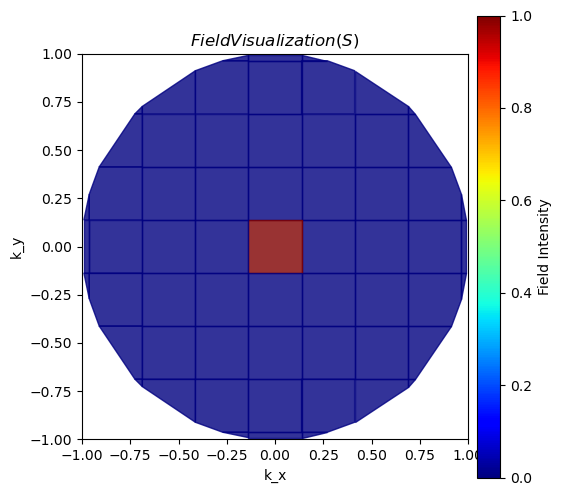

In [14]:
incident_normal_int = np.abs(Es)**2 + np.abs(Ep)**2
dp.plot_field_on_grid(my_grid,incident_normal_int,type = "S")

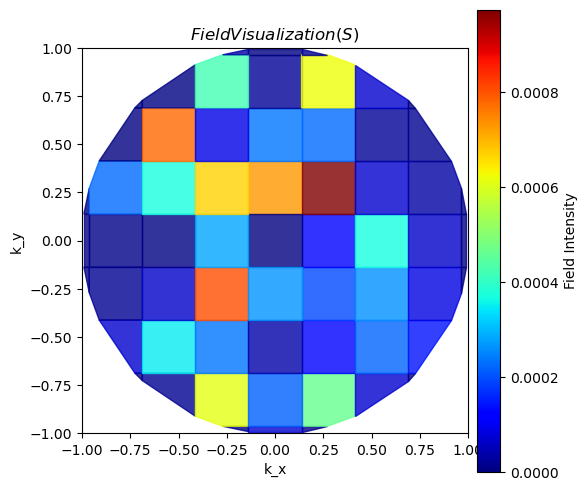

In [15]:
scattered_normal_field = cp.asnumpy(t@E)
scattered_normal_field[mode_slice(n, 0)][0] = 0.0
scattered_normal_field[mode_slice(n, 0)][1] = 0.0
Es_scattered = scattered_normal_field[0::2]
Ep_scattered = scattered_normal_field[1::2]
scattered_normal_int = np.abs(Es_scattered)**2+np.abs(Ep_scattered)**2
dp.plot_field_on_grid(my_grid,scattered_normal_int,"S")


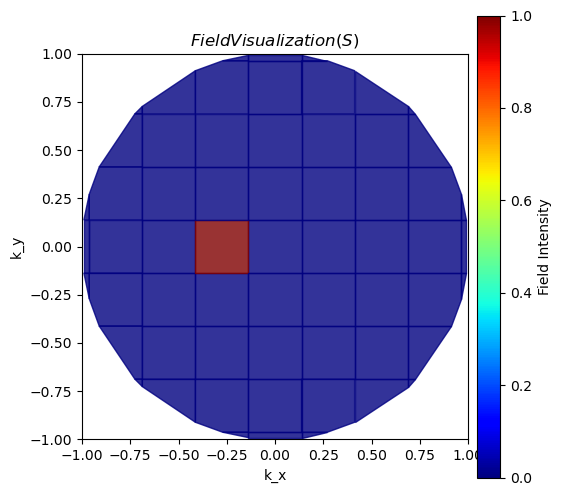

In [34]:
E = np.zeros(2*n,dtype=complex)
E[mode_slice(n, 22)][0] = 1.0
E[mode_slice(n, 0)][1] = 0.0
Es = E[0::2] 
Ep = E[1::2]
incident_normal_int = np.abs(Es)**2 + np.abs(Ep)**2
dp.plot_field_on_grid(my_grid,incident_normal_int,type = "S")

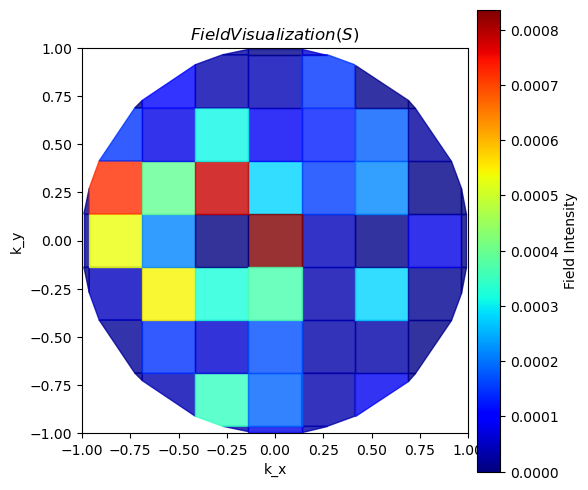

In [35]:
scattered_normal_field = cp.asnumpy(t@E)
scattered_normal_field[mode_slice(n, 22)][0] = 0.0
scattered_normal_field[mode_slice(n, 22)][1] = 0.0
Es_scattered = scattered_normal_field[0::2]
Ep_scattered = scattered_normal_field[1::2]
scattered_normal_int = np.abs(Es_scattered)**2+np.abs(Ep_scattered)**2
dp.plot_field_on_grid(my_grid,scattered_normal_int,"S")

100%|██████████| 61/61 [00:00<00:00, 235.48it/s]


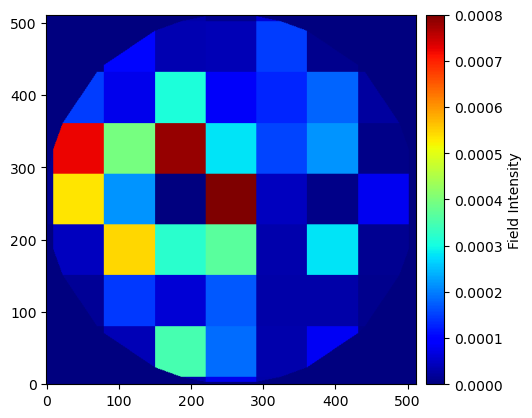

In [36]:
from matplotlib.path import Path
max_idx = my_grid.max_index
min_idx = -max_idx
Es_grid = np.zeros_like(kx, dtype=complex)
Ep_grid = np.zeros_like(kx, dtype=complex)
for idx,i in enumerate(tqdm(range(min_idx, max_idx + 1))):
    mode0 = my_grid.by_index(i)
    centre = (mode0.center)
    kz = (1-centre[0]**2 - centre[1]**2)*k**2
    kz = np.sqrt(kz)
    
    vertices = (mode0.vertices) *k
    points = np.vstack((kx.ravel(), ky.ravel())).T
    square_path = Path(vertices)
    mode = square_path.contains_points(points).reshape(kx.shape)
    # Update Ex_grid with the contribution from this mode and propagation phase
    Es_grid+= mode*((Es_scattered[idx]))*np.exp(1j*kz*z)
    Ep_grid+= mode*((Ep_scattered[idx]))*np.exp(1j*kz*z)

norm = plt.Normalize(
    vmin=0,#np.min(np.abs(Es_scattered)**2 + np.abs(Ep_scattered)**2)
    vmax=0.0008#np.max(np.abs(Es_scattered)**2 + np.abs(Ep_scattered)**2)
)
cmap = plt.cm.jet
ax = plt.gca()

img = ax.imshow(
    np.abs(Es_grid)**2 + np.abs(Ep_grid)**2,
    origin = 'lower',
    cmap=cmap,
    norm=norm
)

# Add colorbar linked to the image
plt.colorbar(img, ax=ax, orientation="vertical", pad=0.02, label="Field Intensity")


In [37]:

center_list = [mode.center for mode in my_grid.propagating_modes_list]
centre_kx =  np.array([center[0] for center in center_list])
centre_ky =  np.array([center[1] for center in center_list])
centre_kz = np.sqrt(1-centre_kx**2-centre_ky**2)
# Convert to x,y,z components
e_theta, e_phi = get_e_theta_phi(centre_kx, centre_ky, centre_kz)
E_x = Es_scattered*(e_phi[:,0])+Ep_scattered*(e_theta[:,0])
E_y = Es_scattered*(e_phi[:,1])+Ep_scattered*(e_theta[:,1])
E_z = Es_scattered*(e_phi[:,2])+Ep_scattered*(e_theta[:,2])

/tmp/ipykernel_1235901/3847078196.py:22: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/tmp/ipykernel_1235901/3847078196.py:39: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


In [38]:
import matplotlib
max_idx = my_grid.max_index
min_idx = -max_idx
ift_modes = np.zeros((2*max_idx+1,Nx,Nx), dtype=complex)
# IFT modes
for idx, i in enumerate(tqdm(range(min_idx, max_idx + 1))):
    mode0 = my_grid.by_index(i)
    centre = (mode0.center)
    kz = (1-centre[0]**2 - centre[1]**2)*k**2
    kz = np.sqrt(kz)
    
    vertices = (mode0.vertices)*k 
    points = np.vstack((kx.ravel(), ky.ravel())).T
    square_path = matplotlib.path.Path(vertices)
    mode = square_path.contains_points(points).reshape(kx.shape)*(np.exp(1j*kz*z)) 

    row_czt = np.array([ (1/(2*np.pi))*dkx*px*czt(row, Nx, Wx, Ax) for row in mode])
    ift_modes[idx] = np.array([ (1/(2*np.pi))*dkx*px*czt(col, Nx, Wx, Ay) for col in row_czt.T]).T

# multiplying with corresponding mode average of field
Ex_rs_grid = sum((E_x[i]*  ift_modes[i, :, :] for i in range(2 * max_idx + 1)))
Ey_rs_grid = sum((E_y[i] * ift_modes[i, :, :] for i in range(2 * max_idx + 1)))
Ez_rs_grid = sum((E_z[i] *ift_modes[i, :, :] for i in range(2 * max_idx + 1)))


100%|██████████| 61/61 [00:13<00:00,  4.62it/s]


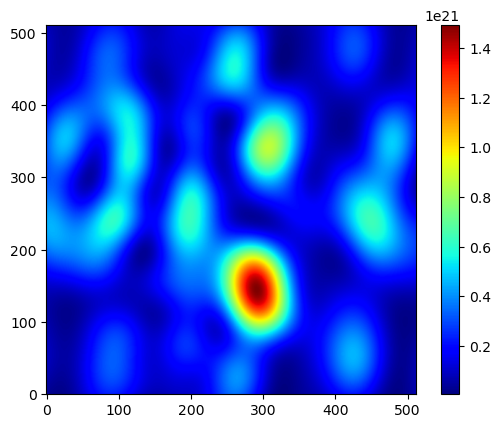

In [39]:
plt.imshow(np.abs(Ex_rs_grid)**2 + np.abs(Ey_rs_grid)**2 + np.abs(Ez_rs_grid)**2, origin='lower', cmap='jet')
plt.colorbar()

In [ ]:
cov_path = Path('/mnt/raid/rmt/data/memory_effect_test/cov.npz')
cov = scipy.sparse.load_npz(cov_path)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 8716176 stored elements and shape (59536, 59536)>

In [100]:
from random_matrix.utils import matrix_utils

In [105]:
print(matrix_utils.get_cov_sub_block(cov, "t,t", (0,22,0,22)).todense())
print(matrix_utils.get_cov_sub_block(cov, "t,t", (0,22,22,14)).todense())
print(matrix_utils.get_cov_sub_block(cov, "t,t", (0,-30,22,-20)).todense())


[[ 3.49338886e-04-8.36204017e-21j  2.08959165e-21-4.03559309e-24j
  -2.30234660e-21-7.99300987e-24j  3.60654400e-04+6.39749283e-07j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 3.60654400e-04-6.39749283e-07j  2.15726869e-21-7.99300987e-24j
  -2.37693706e-21-4.03559309e-24j  3.72337609e-04-1.67240803e-20j]]
[[-1.87479558e-04+1.96477568e-07j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -1.94734701e-04-2.09196281e-07j]
 [-1.12142257e-21-9.90537659e-25j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -1.16481496e-21-3.50091234e-24j]
 [ 1.23559492e-21-5.58450689e-24j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  1.28341982e-21-3.07688061e-24j]
 [-1.93551890e-04+5.46175704e-07j  0.00000000e+00+0.00000000e+00j
  

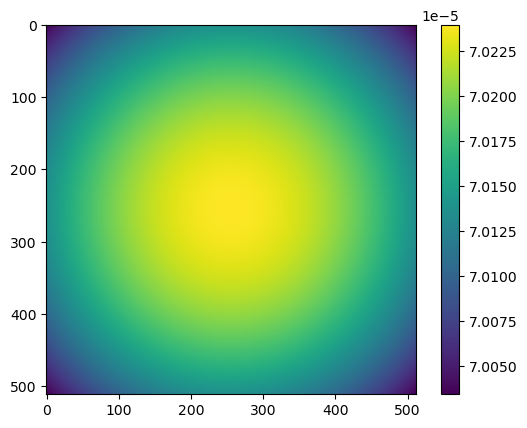

In [38]:
from scipy.signal import czt
# Inverse CZT to get back the square aperture
row_czt = np.array([(1/(2*np.pi))*dkx*px*czt(row, Nx, Wx, Ax) for row in Ex_grid])
Ex_ift = np.array([(1/(2*np.pi))*dkx*px*czt(col, Nx, Wx, Ax) for col in row_czt.T]).T

plt.imshow(np.real(Ex_ift))
plt.colorbar()

In [53]:
analysis_points = [800]
def scatter(matrices):
    ts = matrix_utils.get_block(matrices, "t")
    num_modes = (ts[0].shape[1])//2
  
    # Initialize zero array
    Es = cp.zeros(num_modes)
    Ep = cp.zeros(num_modes)
    # Compute 1/sqrt(2)
    val = 1 / np.sqrt(2)
    # Set the central pair

    Es[(num_modes-1)//2] = val
    Ep[(num_modes-1)//2] = val

    # Create interleaved array
    E= cp.empty(Es.size + Ep.size, dtype=Es.dtype)
    E[0::2] = Es
    E[1::2] = Ep
    
    mean_intensity = cp.zeros(len(E))
    for i,t in enumerate(ts):
        scattered_field = t@E
        mean_intensity += cp.abs(scattered_field)**2

    return mean_intensity/len(ts)


analysis_functions = {"scatter": scatter}

num_real = 1
data = pool.cascade(num_real, analysis_points, analysis_functions)


100%|██████████| 800/800 [00:01<00:00, 407.94it/s]

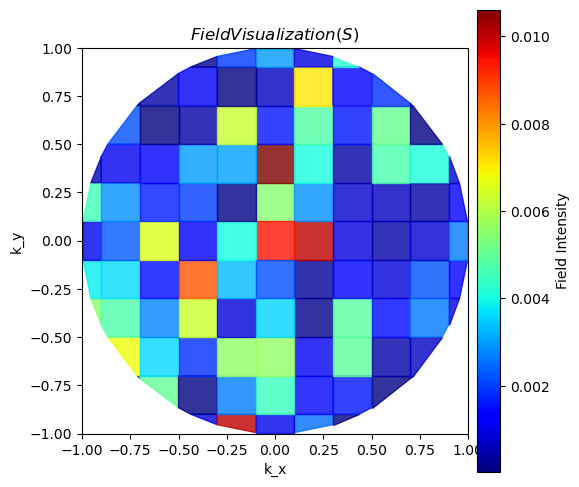

In [74]:
S = data.get("scatter")[0]
a_s = cp.asnumpy(S[::2])
a_p = cp.asnumpy(S[1::2])
dp.plot_field_on_grid(my_grid,a_s,"S")